# Econometrics I

```
TA Christian Alemán
```

**Session 4: Friday 11, February 2022**

Based on Prof. Michael Creel's Lecture Notes and Fumio Hayashi's Book Econometrics section 1.7

**Activity 1: "Replicating Nerlove"**

Nerlove's 1963 paper is a classic study of returns to scale in a regulated industry.

Firms Minimize Cost:

$$C = p_{l}l+p_{f}f+p_{k}k$$

Subject to a Constant Returns to Scale Production Function (Cobb-Douglas)

$$Q = F\,l^{\alpha_{1}}\,f^{\alpha_{2}}\,k^{\alpha_{3}}$$

Where $l,f,k$ are the inputs, labor, fuel and capital respectively.

Equilibrium prices are respectively $p_{l},p_{f},p_{k}$.

Recall that we have constant returns to scale if:

$$\sum_{i}\alpha_{i} = r = 1$$

Solving the minimization problem we find that the Cost Function is also Cobb-Douglas:

$$C = A\,Q^{1/r}\,p_{l}^{\alpha_{1}/r}\,p_{f}^{\alpha_{2}/r}\,p_{k}^{\alpha_{3}/r}\,e^{\epsilon}$$

What's more, the cost function above will be homogeneous of degree 1 (HOD1) if $\sum_{i}\alpha_{i}/r = 1$

We can rewrite the above cost function as:

$$C = A\,Q^{\beta_{1}}\,p_{l}^{\beta_{2}}\,p_{f}^{\beta_{3}}\,p_{k}^{\beta_{4}}\,e^{\epsilon}$$

Take the logs

$$ln(C) = \beta_{1} +\beta_{2}ln(Q)+\beta_{3}ln(p_{l})+\beta_{4}ln(p_{f})+\beta_{5}ln(p_{l})+ \epsilon$$

**Our Data**

Data on Company's:

1. COST(C)
2. OUTPUT(Q)
3. PRICE OF LABOR $(p_{L})$
4. PRICE OF FUEL $(p_{f})$
5. PRICE OF CAPITAL $(p_{K})$

We are ready to run some tests!

We want to test:

1. Constant Returns to Scale (CRS) assumption
2. Homogeneity of degree 1
3. Understand whether CRS changes with size of the company

Our Tools:

1. Restricted estimation:
2. Testing: Chow-test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def ols(y, x):
    '''
    Simple OLS regression
    '''
    t = x.shape[0]
    beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
    e = y - x @ beta
    sigma = (e @ e) / (t - np.linalg.matrix_rank(x))
    return beta, sigma, e


def eemult_mv(m, v):
    if m.ndim != 2:
        raise ValueError('eemult_mv: first arg must be a matrix')
    v = np.asarray(v)
    if v.ndim != 1:
        raise ValueError('eemult_mv: second arg must be a vector')
    rm, cm = m.shape
    rv = v.shape[0]
    if rm == rv:
        result = m * v[:, None]
    elif cm == rv:
        result = m * v[None, :]
    else:
        raise ValueError('eemult_mv: dimension of vector must match one of the dimensions of the matrix')
    return result


def het_consistent_variance(x, e):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation
    '''
    xx_inv = np.linalg.inv(x.T @ x)
    E = e ** 2
    return xx_inv @ (x.T @ eemult_mv(x, E)) @ xx_inv


def prettyprint(mat, rlabels, clabels):
    '''
    This function prints matrices with row and column labels

    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation
    '''
    header = ''.join(f'{c:>10}  ' for c in clabels)
    print('   ' + header)
    for i in range(mat.shape[0]):
        row_vals = ''.join(f'{v:10.3f}' for v in mat[i, :])
        print(f'{str(rlabels[i]):<10}{row_vals}')


def mc_ols(y, x, names=None, silent=False, regularvc=False):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation

    Calculates ordinary LS estimator using the Huber-White heteroscedastic
    consistent variance estimator.

    inputs:
    y: dep variable
    x: matrix of regressors
    names (optional) names of regressors
    silent (bool) default false. controls screen output
    regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)

    outputs:
    b: estimated coefficients
    varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
    e: ols residuals
    ess: sum of squared residuals
    '''
    k = x.shape[1]
    if names is None or len(names) != k:
        names = [str(i + 1) for i in range(k)]

    b, sigsq, e = ols(y, x)
    xx_inv = np.linalg.inv(x.T @ x)
    n = x.shape[0]
    ess = e @ e

    if regularvc:
        varb = xx_inv * sigsq
    else:
        varb = het_consistent_variance(x, e)

    seb = np.sqrt(np.diag(varb))
    t = b / seb

    tss = y - y.mean()
    tss = tss @ tss
    rsq = 1 - ess / tss

    if not silent:
        print('*' * 57)
        print('OLS estimation results')
        print(f'Observations {n}')
        print(f'R-squared {rsq:.6f}')
        print(f'Sigma-squared {sigsq:.6f}')
        p = 2 - 2 * stats.t.cdf(np.abs(t), n - k)
        results = np.column_stack([b, seb, t, p])
        if regularvc:
            print('\nResults (Ordinary var-cov estimator)\n')
        else:
            print('\nResults (Het. consistent var-cov estimator)\n')
        prettyprint(results, names, ['estimate', 'st.err.', 't-stat.', 'p-value'])
        print('\n' + '*' * 57)

    return b, varb, e, ess


def mc_olsr(y, x, R, r, names=None, silent=False, regularvc=False):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation

    Calculates restricted LS estimator (subject to Rb=r) using the Huber-White heteroscedastic
    consistent variance estimator.

    inputs:
    y: dep variable
    x: matrix of regressors
    R: matrix R in Rb=r
    r: vector r in Rb=r
    names (optional) names of regressors
    silent (bool) default false. controls screen output
    regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)

    outputs:
    b: estimated coefficients
    varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
    e: ols residuals
    '''
    k = x.shape[1]
    if names is None or len(names) != k:
        names = [str(i + 1) for i in range(k)]

    b, sigsq, e = ols(y, x)
    xx_inv = np.linalg.inv(x.T @ x)
    n, k = x.shape
    q = R.shape[0]

    P_inv = np.linalg.inv(R @ xx_inv @ R.T)
    b = b - xx_inv @ R.T @ P_inv @ (R @ b - r)

    e = y - x @ b
    ess = e @ e
    sigsq = ess / (n - k - q)

    if regularvc:
        varb = xx_inv * sigsq
    else:
        varb = het_consistent_variance(x, e)

    A = np.eye(k) - xx_inv @ R.T @ P_inv @ R
    varb = A @ varb @ A.T
    seb = np.sqrt(np.diag(varb))
    with np.errstate(divide='ignore', invalid='ignore'):
        t = b / seb

    tss = y - y.mean()
    tss = tss @ tss
    rsq = 1 - ess / tss

    if not silent:
        print('*' * 57)
        print('Restricted LS estimation results')
        print(f'Observations {n}')
        print(f'R-squared {rsq:.6f}')
        print(f'Sigma-squared {sigsq:.6f}')
        with np.errstate(divide='ignore', invalid='ignore'):
            p = 2 - 2 * stats.t.cdf(np.abs(t), n - k - q)
        results = np.column_stack([b, seb, t, p])
        if regularvc:
            print('\nResults (Ordinary var-cov estimator)\n')
        else:
            print('\nResults (Het. consistent var-cov estimator)\n')
        prettyprint(results, names, ['estimate', 'st.err.', 't-stat.', 'p-value'])
        print('\n' + '*' * 57)

    return b, varb, e


def test_statistics(y, x, R, r):
    '''
    Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
    This program is free software; you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation

    This code calculates F, Wald, Score and Likelihood Ratio tests for
    linear model y=XB+e e~N(0,sig^2*I_n) subject to linear restrictions RB=r

    The null is H_{0}:RB=r
    inputs:
    y: nx1 dependent variable
    x: nxk regressor matrix
    R: R above, a qxk matrix
    r: r above, a qx1 vector

    output: F: the F statistic
    W: the Wald statistic
    S: the score statistic
    LR: the likelihood ratio statistic
    '''
    n, k = x.shape
    q = R.shape[0]

    b, _, _ = ols(y, x)

    xx_inv = np.linalg.inv(x.T @ x)
    P_inv = np.linalg.inv(R @ xx_inv @ R.T)
    b_r = b - xx_inv @ R.T @ P_inv @ (R @ b - r)

    # Sums of squared errors and estimators of sig^2
    e = y - x @ b
    ess = e @ e
    e_r = y - x @ b_r
    ess_r = e_r @ e_r
    sigsqhat_ols = ess / (n - k)
    sigsqhat_mle = ess / n
    sigsqhat_mle_r = ess_r / n

    # F-test
    F = (ess_r - ess) / q
    F = F / sigsqhat_ols

    # Wald test (uses unrestricted model's est. of sig^2)
    W = (R @ b - r) @ P_inv @ (R @ b - r) / sigsqhat_mle

    # Score test (uses restricted model's est. of sig^2)
    P_x = x @ xx_inv @ x.T
    S = e_r @ P_x @ e_r / sigsqhat_mle_r

    # LR test
    lnl = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigsqhat_mle) - e @ e / (2 * sigsqhat_mle)
    lnl_r = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigsqhat_mle_r) - e_r @ e_r / (2 * sigsqhat_mle_r)
    LR = 2 * (lnl - lnl_r)

    tests = np.array([F, W, LR, S])
    WLRS = np.array([W, LR, S])
    pvalues = np.concatenate([[1 - stats.f.cdf(F, q, n - k)], 1 - stats.chi2.cdf(WLRS, q)])
    results = np.column_stack([tests, pvalues])

    prettyprint(results, ['F', 'Wald', 'LR', 'Score'], ['Value', 'p-value'])
    return F, W, LR, S


In [2]:
data = pd.read_csv('nerlove.csv')
data = data[['cost', 'output', 'labor', 'fuel', 'capital']].to_numpy()
data = np.log(data)
n = data.shape[0]
y = data[:, 0]
x = data[:, 1:5]
x = np.column_stack([np.ones(n), x])
k = x.shape[1]

names = ['constant', 'output', 'labor', 'fuel', 'capital']
names = names * 5   # copy 5 times for Chow test

b, varb, e, ess = mc_ols(y, x, names, False, True)


*********************************************************
OLS estimation results
Observations 145
R-squared 0.925955
Sigma-squared 0.153943

Results (Ordinary var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
1             -3.527     1.774    -1.987     0.049
2              0.720     0.017    41.244     0.000
3              0.436     0.291     1.499     0.136
4              0.427     0.100     4.249     0.000
5             -0.220     0.339    -0.648     0.518

*********************************************************


**Activity 2: Testing**

**Testing Homogeneity of Degree 1**

Recall the linear restriction form:

$$R\beta = r$$

In our case for HOD1 we need $r=1$ and $R=(0,0,1,1,1)$

The null hypothesis for qF,Wald,LR test below is:

$$H_{0}: R\beta = r$$
$$H_{1}: R\beta \neq r$$

We cannot reject the null (the p-value is above 0.05), meaning that we cannot reject Homogeneity

In [3]:
# First Homogeneity of Degree 1 (HOD1)
R = np.array([[0.0, 0.0, 1.0, 1.0, 1.0]])
r = np.array([1.0])
# Imposing and testing HOD1
mc_olsr(y, x, R, r, names);
test_statistics(y, x, R, r);


*********************************************************
Restricted LS estimation results
Observations 145
R-squared 0.925652
Sigma-squared 0.155686

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
1             -4.691     0.804    -5.838     0.000
2              0.721     0.032    22.516     0.000
3              0.593     0.167     3.556     0.001
4              0.414     0.072     5.768     0.000
5             -0.007     0.154    -0.048     0.962

*********************************************************
        Value     p-value  
F              0.574     0.450
Wald           0.594     0.441
LR             0.593     0.441
Score          0.592     0.442


**Testing Constant Returns to scale (CRS)**

In our case for CRS we need $r=1$ and $R=(0,1,0,0,0)$

$$H_{0}: R\beta = r$$
$$H_{1}: R\beta \neq r$$

We reject the null (the p-value is below 0.05), meaning that we reject the assumption of constant returns to scale.

In [4]:
# Now Constant Returns to Scale (CRTS)
R = np.array([[0.0, 1.0, 0.0, 0.0, 0.0]])
r = np.array([1.0])
# Imposing and testing CRTS
mc_olsr(y, x, R, r, names);
test_statistics(y, x, R, r);


*********************************************************
Restricted LS estimation results
Observations 145
R-squared 0.790420
Sigma-squared 0.438861

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
1             -7.530     2.919    -2.579     0.011
2              1.000     0.000       inf     0.000
3              0.020     0.376     0.052     0.959
4              0.715     0.159     4.490     0.000
5              0.076     0.576     0.132     0.896

*********************************************************
        Value     p-value  
F            256.262     0.000
Wald         265.414     0.000
LR           150.863     0.000
Score         93.771     0.000


**Activity 3: The chow test**

We want to understand whether CRS changes with size of the company

Define 5 subsamples of firms, with the first group being the 29 firms with the lowest output levels, then the next 29 firms, etc.

To do this define dummy variables:

$$D_{1}=\begin{cases}1\, t\in\{1,2,...,29\}\end{cases}, 0 \text{ Otherwise}$$
$$D_{2}=\begin{cases}1\, t\in\{30,31,...,58\}\end{cases}, 0 \text{ Otherwise}$$

And so forth for $D_{3},...,D_{5}$

Then the model can be rewritten as:

$$ln(C) = \sum_{j}^{5}D_{j}\beta_{1} +\sum_{j}^{5}D_{j}\beta_{2,j}ln(Q)+\sum_{j}^{5}D_{j}\beta_{3,j}ln(Pl)+\sum_{j}^{5}D_{j}\beta_{4,j}ln(Pf)+\sum_{j}^{5}D_{j}\beta_{5,j}ln(Pl)+ \epsilon$$

In Matrix form

$$\left[\begin{array}{c}y_{1} \\ y_{2} \\ y_{3} \\ y_{4} \\ y_{5}  \end{array}\right]=\left[\begin{array}{ccccc}X_{1}&0&0&0&0 \\ 0&X_{2}&0&0&0 \\ 0&0&X_{3}&0&0 \\ 0&0&0&X_{4}&0 \\ 0&0&0&0&X_{5}  \end{array}\right]\left[\begin{array}{c}\beta^{1} \\ \beta^{2} \\ \beta^{3} \\ \beta^{4} \\ \beta^{5}  \end{array}\right]\left[\begin{array}{c}\epsilon_{1} \\ \epsilon_{2} \\ \epsilon_{3} \\ \epsilon_{4} \\ \epsilon_{5}  \end{array}\right]$$

We define $\beta^{j} = (\beta_{1},\beta_{2,j},\beta_{3,j},\beta_{4,j},\beta_{5,j})$

In [5]:
# Create the block diagonal X matrix corresponding to separate coefficients
big_x = np.zeros((n, 5 * k))
x_old = x
for i in range(k):
    startrow = i * 29
    endrow = (i + 1) * 29
    startcol = i * k
    endcol = (i + 1) * k
    big_x[startrow:endrow, startcol:endcol] = (
        big_x[startrow:endrow, startcol:endcol] + x[startrow:endrow, :]
    )
x = big_x


**Visual Inspection**

Nerlove model: 5 separate regressions, one per each group of firms

*********************************************************
OLS estimation results
Observations 145
R-squared 0.960901
Sigma-squared 0.094836

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
constant       0.390     4.049     0.096     0.923
output         0.385     0.089     4.315     0.000
labor         -0.177     0.894    -0.198     0.844
fuel           0.406     0.255     1.591     0.114
capital       -0.650     0.744    -0.873     0.384
constant      -0.569     1.937    -0.294     0.769
output         0.655     0.077     8.490     0.000
labor         -0.522     0.284    -1.834     0.069
fuel           0.511     0.090     5.669     0.000
capital       -0.681     0.375    -1.819     0.071
constant      -2.146     1.724    -1.245     0.216
output         0.957     0.135     7.095     0.000
labor         -0.335     0.208    -1.610     0.110
fuel           0.409     0.120     3.408     0.001
capital       -0.722     0.264    -2.739     0.0

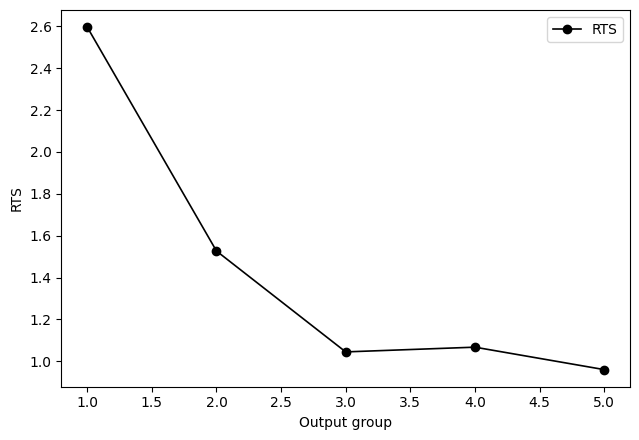

In [6]:
b, varb, e, ess = mc_ols(y, x, names)
group = np.arange(1, 6)
output_idx = (group - 1) * 5 + 1     # Just extract the relevant parameter
output_coef = b[output_idx]
rts = 1 / output_coef

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(group, rts, 'ko-', linewidth=1.2, markerfacecolor='k')
ax.set_ylabel('RTS')
ax.set_xlabel('Output group')
ax.legend(['RTS'])
plt.tight_layout()
plt.show()


**Chow test**

When performing the Chow Test the null to test is that the parameter vectors for the separate groups are all the same, that is:

$$H_{0}: \beta^{1}=\beta^{2}=...=\beta^{5}$$

We reject the null, then the estimated coefficients are different for the 5 groups.

In [7]:
R5 = np.eye(5)
Z = np.zeros((5, 5))
R = np.block([
    [R5, -R5, Z, Z, Z],
    [R5, Z, -R5, Z, Z],
    [R5, Z, Z, -R5, Z],
    [R5, Z, Z, Z, -R5],
])
r = np.zeros(20)

# Chow test:
mc_olsr(y, x, R, r, names);
test_statistics(y, x, R, r);


*********************************************************
Restricted LS estimation results
Observations 145
R-squared 0.925955
Sigma-squared 0.215520

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.691     0.491
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.691     0.491
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.6

Pick another reference, results should be the same

Chow test: note that the restricted model gives the same results as the original model

In [8]:
R5 = np.eye(5)
Z = np.zeros((5, 5))
R = np.block([
    [-R5, Z, Z, Z, R5],
    [Z, -R5, Z, R5, Z],
    [Z, Z, -R5, Z, R5],
    [-R5, R5, Z, Z, Z],
])
r = np.zeros(20)

mc_olsr(y, x, R, r, names);
test_statistics(y, x, R, r);


*********************************************************
Restricted LS estimation results
Observations 145
R-squared 0.925955
Sigma-squared 0.215520

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.691     0.491
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.691     0.491
constant      -3.527     1.689    -2.088     0.039
output         0.720     0.032    22.491     0.000
labor          0.436     0.241     1.808     0.074
fuel           0.427     0.074     5.751     0.000
capital       -0.220     0.318    -0.6

**Run the Chow test only the last two groups:**

In [9]:
# Trim the data
# ng: Choose number of groups:
ng = 2
ni = 5 - ng
y = y[29 * ni:]
x = x[29 * ni:, 5 * ni:]

R5 = np.eye(5)
R = np.hstack([R5, -R5])
r = np.zeros(5 * (ng - 1))


Chow test: note that we still reject the null, but only at the 95% level, not at 90% anymore

In [10]:
mc_olsr(y, x, R, r, names);
test_statistics(y, x, R, r);


*********************************************************
Restricted LS estimation results
Observations 58
R-squared 0.961866
Sigma-squared 0.026330

Results (Het. consistent var-cov estimator)

     estimate     st.err.     t-stat.     p-value  
1             -5.526     1.437    -3.844     0.000
2              0.944     0.037    25.746     0.000
3              0.616     0.180     3.430     0.001
4              0.434     0.056     7.694     0.000
5             -0.190     0.257    -0.740     0.463
6             -5.526     1.437    -3.844     0.000
7              0.944     0.037    25.746     0.000
8              0.616     0.180     3.430     0.001
9              0.434     0.056     7.694     0.000
10            -0.190     0.257    -0.740     0.463

*********************************************************
        Value     p-value  
F              2.487     0.044
Wald          15.028     0.010
LR            13.363     0.020
Score         11.936     0.036


This markdown was constructed based on the IPYNB code below.

In [11]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
#
#
# def ols(y, x):
#     '''
#     Simple OLS regression
#     '''
#     t = x.shape[0]
#     beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
#     e = y - x @ beta
#     sigma = (e @ e) / (t - np.linalg.matrix_rank(x))
#     return beta, sigma, e
#
#
# def eemult_mv(m, v):
#     if m.ndim != 2:
#         raise ValueError('eemult_mv: first arg must be a matrix')
#     v = np.asarray(v)
#     if v.ndim != 1:
#         raise ValueError('eemult_mv: second arg must be a vector')
#     rm, cm = m.shape
#     rv = v.shape[0]
#     if rm == rv:
#         result = m * v[:, None]
#     elif cm == rv:
#         result = m * v[None, :]
#     else:
#         raise ValueError('eemult_mv: dimension of vector must match one of the dimensions of the matrix')
#     return result
#
#
# def het_consistent_variance(x, e):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#     '''
#     xx_inv = np.linalg.inv(x.T @ x)
#     E = e ** 2
#     return xx_inv @ (x.T @ eemult_mv(x, E)) @ xx_inv
#
#
# def prettyprint(mat, rlabels, clabels):
#     '''
#     This function prints matrices with row and column labels
#
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#     '''
#     header = ''.join(f'{c:>10}  ' for c in clabels)
#     print('   ' + header)
#     for i in range(mat.shape[0]):
#         row_vals = ''.join(f'{v:10.3f}' for v in mat[i, :])
#         print(f'{str(rlabels[i]):<10}{row_vals}')
#
#
# def mc_ols(y, x, names=None, silent=False, regularvc=False):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#
#     Calculates ordinary LS estimator using the Huber-White heteroscedastic
#     consistent variance estimator.
#
#     inputs:
#     y: dep variable
#     x: matrix of regressors
#     names (optional) names of regressors
#     silent (bool) default false. controls screen output
#     regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)
#
#     outputs:
#     b: estimated coefficients
#     varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
#     e: ols residuals
#     ess: sum of squared residuals
#     '''
#     k = x.shape[1]
#     if names is None or len(names) != k:
#         names = [str(i + 1) for i in range(k)]
#
#     b, sigsq, e = ols(y, x)
#     xx_inv = np.linalg.inv(x.T @ x)
#     n = x.shape[0]
#     ess = e @ e
#
#     if regularvc:
#         varb = xx_inv * sigsq
#     else:
#         varb = het_consistent_variance(x, e)
#
#     seb = np.sqrt(np.diag(varb))
#     t = b / seb
#
#     tss = y - y.mean()
#     tss = tss @ tss
#     rsq = 1 - ess / tss
#
#     if not silent:
#         print('*' * 57)
#         print('OLS estimation results')
#         print(f'Observations {n}')
#         print(f'R-squared {rsq:.6f}')
#         print(f'Sigma-squared {sigsq:.6f}')
#         p = 2 - 2 * stats.t.cdf(np.abs(t), n - k)
#         results = np.column_stack([b, seb, t, p])
#         if regularvc:
#             print('\nResults (Ordinary var-cov estimator)\n')
#         else:
#             print('\nResults (Het. consistent var-cov estimator)\n')
#         prettyprint(results, names, ['estimate', 'st.err.', 't-stat.', 'p-value'])
#         print('\n' + '*' * 57)
#
#     return b, varb, e, ess
#
#
# def mc_olsr(y, x, R, r, names=None, silent=False, regularvc=False):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#
#     Calculates restricted LS estimator (subject to Rb=r) using the Huber-White heteroscedastic
#     consistent variance estimator.
#
#     inputs:
#     y: dep variable
#     x: matrix of regressors
#     R: matrix R in Rb=r
#     r: vector r in Rb=r
#     names (optional) names of regressors
#     silent (bool) default false. controls screen output
#     regularvc (bool) default false. use normal varcov estimator, instead of het consistent (default)
#
#     outputs:
#     b: estimated coefficients
#     varb: estimated covariance matrix of coefficients (Huber-White by default, ordinary OLS if requested with switch)
#     e: ols residuals
#     '''
#     k = x.shape[1]
#     if names is None or len(names) != k:
#         names = [str(i + 1) for i in range(k)]
#
#     b, sigsq, e = ols(y, x)
#     xx_inv = np.linalg.inv(x.T @ x)
#     n, k = x.shape
#     q = R.shape[0]
#
#     P_inv = np.linalg.inv(R @ xx_inv @ R.T)
#     b = b - xx_inv @ R.T @ P_inv @ (R @ b - r)
#
#     e = y - x @ b
#     ess = e @ e
#     sigsq = ess / (n - k - q)
#
#     if regularvc:
#         varb = xx_inv * sigsq
#     else:
#         varb = het_consistent_variance(x, e)
#
#     A = np.eye(k) - xx_inv @ R.T @ P_inv @ R
#     varb = A @ varb @ A.T
#     seb = np.sqrt(np.diag(varb))
#     with np.errstate(divide='ignore', invalid='ignore'):
#         t = b / seb
#
#     tss = y - y.mean()
#     tss = tss @ tss
#     rsq = 1 - ess / tss
#
#     if not silent:
#         print('*' * 57)
#         print('Restricted LS estimation results')
#         print(f'Observations {n}')
#         print(f'R-squared {rsq:.6f}')
#         print(f'Sigma-squared {sigsq:.6f}')
#         with np.errstate(divide='ignore', invalid='ignore'):
#             p = 2 - 2 * stats.t.cdf(np.abs(t), n - k - q)
#         results = np.column_stack([b, seb, t, p])
#         if regularvc:
#             print('\nResults (Ordinary var-cov estimator)\n')
#         else:
#             print('\nResults (Het. consistent var-cov estimator)\n')
#         prettyprint(results, names, ['estimate', 'st.err.', 't-stat.', 'p-value'])
#         print('\n' + '*' * 57)
#
#     return b, varb, e
#
#
# def test_statistics(y, x, R, r):
#     '''
#     Copyright (C) 2010 Michael Creel <michael.creel@uab.es>
#     This program is free software; you can redistribute it and/or modify
#     it under the terms of the GNU General Public License as published by
#     the Free Software Foundation
#
#     This code calculates F, Wald, Score and Likelihood Ratio tests for
#     linear model y=XB+e e~N(0,sig^2*I_n) subject to linear restrictions RB=r
#
#     The null is H_{0}:RB=r
#     inputs:
#     y: nx1 dependent variable
#     x: nxk regressor matrix
#     R: R above, a qxk matrix
#     r: r above, a qx1 vector
#
#     output: F: the F statistic
#     W: the Wald statistic
#     S: the score statistic
#     LR: the likelihood ratio statistic
#     '''
#     n, k = x.shape
#     q = R.shape[0]
#
#     b, _, _ = ols(y, x)
#
#     xx_inv = np.linalg.inv(x.T @ x)
#     P_inv = np.linalg.inv(R @ xx_inv @ R.T)
#     b_r = b - xx_inv @ R.T @ P_inv @ (R @ b - r)
#
#     # Sums of squared errors and estimators of sig^2
#     e = y - x @ b
#     ess = e @ e
#     e_r = y - x @ b_r
#     ess_r = e_r @ e_r
#     sigsqhat_ols = ess / (n - k)
#     sigsqhat_mle = ess / n
#     sigsqhat_mle_r = ess_r / n
#
#     # F-test
#     F = (ess_r - ess) / q
#     F = F / sigsqhat_ols
#
#     # Wald test (uses unrestricted model's est. of sig^2)
#     W = (R @ b - r) @ P_inv @ (R @ b - r) / sigsqhat_mle
#
#     # Score test (uses restricted model's est. of sig^2)
#     P_x = x @ xx_inv @ x.T
#     S = e_r @ P_x @ e_r / sigsqhat_mle_r
#
#     # LR test
#     lnl = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigsqhat_mle) - e @ e / (2 * sigsqhat_mle)
#     lnl_r = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigsqhat_mle_r) - e_r @ e_r / (2 * sigsqhat_mle_r)
#     LR = 2 * (lnl - lnl_r)
#
#     tests = np.array([F, W, LR, S])
#     WLRS = np.array([W, LR, S])
#     pvalues = np.concatenate([[1 - stats.f.cdf(F, q, n - k)], 1 - stats.chi2.cdf(WLRS, q)])
#     results = np.column_stack([tests, pvalues])
#
#     prettyprint(results, ['F', 'Wald', 'LR', 'Score'], ['Value', 'p-value'])
#     return F, W, LR, S
#
#
# # ----- next cell -----
#
# data = pd.read_csv('nerlove.csv')
# data = data[['cost', 'output', 'labor', 'fuel', 'capital']].to_numpy()
# data = np.log(data)
# n = data.shape[0]
# y = data[:, 0]
# x = data[:, 1:5]
# x = np.column_stack([np.ones(n), x])
# k = x.shape[1]
#
# names = ['constant', 'output', 'labor', 'fuel', 'capital']
# names = names * 5   # copy 5 times for Chow test
#
# b, varb, e, ess = mc_ols(y, x, names, False, True)
#
#
# # ----- next cell -----
#
# # First Homogeneity of Degree 1 (HOD1)
# R = np.array([[0.0, 0.0, 1.0, 1.0, 1.0]])
# r = np.array([1.0])
# # Imposing and testing HOD1
# mc_olsr(y, x, R, r, names);
# test_statistics(y, x, R, r);
#
#
# # ----- next cell -----
#
# # Now Constant Returns to Scale (CRTS)
# R = np.array([[0.0, 1.0, 0.0, 0.0, 0.0]])
# r = np.array([1.0])
# # Imposing and testing CRTS
# mc_olsr(y, x, R, r, names);
# test_statistics(y, x, R, r);
#
#
# # ----- next cell -----
#
# # Create the block diagonal X matrix corresponding to separate coefficients
# big_x = np.zeros((n, 5 * k))
# x_old = x
# for i in range(k):
#     startrow = i * 29
#     endrow = (i + 1) * 29
#     startcol = i * k
#     endcol = (i + 1) * k
#     big_x[startrow:endrow, startcol:endcol] = (
#         big_x[startrow:endrow, startcol:endcol] + x[startrow:endrow, :]
#     )
# x = big_x
#
#
# # ----- next cell -----
#
# b, varb, e, ess = mc_ols(y, x, names)
# group = np.arange(1, 6)
# output_idx = (group - 1) * 5 + 1     # Just extract the relevant parameter
# output_coef = b[output_idx]
# rts = 1 / output_coef
#
# fig, ax = plt.subplots(figsize=(6.5, 4.5))
# ax.plot(group, rts, 'ko-', linewidth=1.2, markerfacecolor='k')
# ax.set_ylabel('RTS')
# ax.set_xlabel('Output group')
# ax.legend(['RTS'])
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# R5 = np.eye(5)
# Z = np.zeros((5, 5))
# R = np.block([
#     [R5, -R5, Z, Z, Z],
#     [R5, Z, -R5, Z, Z],
#     [R5, Z, Z, -R5, Z],
#     [R5, Z, Z, Z, -R5],
# ])
# r = np.zeros(20)
#
# # Chow test:
# mc_olsr(y, x, R, r, names);
# test_statistics(y, x, R, r);
#
#
# # ----- next cell -----
#
# R5 = np.eye(5)
# Z = np.zeros((5, 5))
# R = np.block([
#     [-R5, Z, Z, Z, R5],
#     [Z, -R5, Z, R5, Z],
#     [Z, Z, -R5, Z, R5],
#     [-R5, R5, Z, Z, Z],
# ])
# r = np.zeros(20)
#
# mc_olsr(y, x, R, r, names);
# test_statistics(y, x, R, r);
#
#
# # ----- next cell -----
#
# # Trim the data
# # ng: Choose number of groups:
# ng = 2
# ni = 5 - ng
# y = y[29 * ni:]
# x = x[29 * ni:, 5 * ni:]
#
# R5 = np.eye(5)
# R = np.hstack([R5, -R5])
# r = np.zeros(5 * (ng - 1))
#
#
# # ----- next cell -----
#
# mc_olsr(y, x, R, r, names);
# test_statistics(y, x, R, r);